## Setup

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
victorsoeiro_amazon_prime_tv_shows_and_movies_path = kagglehub.dataset_download('victorsoeiro/amazon-prime-tv-shows-and-movies')

print('Data source import complete.')

Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk(victorsoeiro_amazon_prime_tv_shows_and_movies_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

C:\Users\aaron\.cache\kagglehub\datasets\victorsoeiro\amazon-prime-tv-shows-and-movies\versions\1\credits.csv
C:\Users\aaron\.cache\kagglehub\datasets\victorsoeiro\amazon-prime-tv-shows-and-movies\versions\1\titles.csv


In [3]:
credits = pd.read_csv(r'C:\Users\aaron\.cache\kagglehub\datasets\victorsoeiro\amazon-prime-tv-shows-and-movies\versions\1\credits.csv')
credits.head()

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


In [4]:
titles = pd.read_csv(r'C:\Users\aaron\.cache\kagglehub\datasets\victorsoeiro\amazon-prime-tv-shows-and-movies\versions\1\titles.csv')

# filtrado de calidad de los datos
titles = titles[~(titles['imdb_score'].isnull() | titles['imdb_votes'].isnull())]
titles = titles[~(titles['imdb_votes'] <= 30)]
titles.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8071 entries, 0 to 9869
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    8071 non-null   object 
 1   title                 8071 non-null   object 
 2   type                  8071 non-null   object 
 3   description           8062 non-null   object 
 4   release_year          8071 non-null   int64  
 5   age_certification     3099 non-null   object 
 6   runtime               8071 non-null   int64  
 7   genres                8071 non-null   object 
 8   production_countries  8071 non-null   object 
 9   seasons               1003 non-null   float64
 10  imdb_id               8071 non-null   object 
 11  imdb_score            8071 non-null   float64
 12  imdb_votes            8071 non-null   float64
 13  tmdb_popularity       7933 non-null   float64
 14  tmdb_score            7104 non-null   float64
dtypes: float64(5), int64(2), o

## Preprocesamiento

In [5]:
def get_credits(id_title, role, credits_df=credits):
    '''
    role es 'DIRECTOR' o 'ACTOR'
    '''
    return str(list(credits_df[(credits_df['id'] == id_title) & (credits_df['role'] == role)]['name'])).replace("'", '')

def transform(dataframe):
    df = dataframe.copy()

    # llena los valores nulos
    df['title'] = df['title'].fillna('')
    df['description'] = df['description'].fillna('')
    df['seasons'] = df['seasons'].fillna(1).astype(int)
    df['age_certification'] = df['age_certification'].fillna('Unrated')

    # elimina comillas
    df['genres'] = df['genres'].str.replace("'", "").str.replace("[", "").str.replace("]", "")
    df['production_countries'] = df['production_countries'].str.replace("'", "").str.replace("[", "").str.replace("]", "")

    # agrega los creditos
    directors = []
    actors = []
    for id_title in df['id']:
        director = get_credits(id_title, 'DIRECTOR')
        actor = get_credits(id_title, 'ACTOR')
        directors.append(director)
        actors.append(actor)
    
    df['directors'] = directors
    df['actors'] = actors

    df['directors'] = df['directors'].str.replace("[", "").str.replace("]", "")
    df['actors'] = df['actors'].str.replace("[", "").str.replace("]", "")
    
    # fija el id como un entero
    df['id'] = df['id'].str.extract(r'(\d+)', expand=False).astype(int)
    df.set_index('id', inplace=True)

    return df[['title', 'type', 'description', 'release_year', 'age_certification', 'runtime', 'genres', 'production_countries', 'seasons', 'directors', 'actors', 'imdb_score']]

titles = transform(titles)
titles.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8071 entries, 20945 to 1054116
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 8071 non-null   object 
 1   type                  8071 non-null   object 
 2   description           8071 non-null   object 
 3   release_year          8071 non-null   int64  
 4   age_certification     8071 non-null   object 
 5   runtime               8071 non-null   int64  
 6   genres                8071 non-null   object 
 7   production_countries  8071 non-null   object 
 8   seasons               8071 non-null   int64  
 9   directors             8071 non-null   object 
 10  actors                8071 non-null   object 
 11  imdb_score            8071 non-null   float64
dtypes: float64(1), int64(3), object(8)
memory usage: 819.7+ KB


In [6]:
titles.head()

,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,directors,actors,imdb_score
id,,,,,,,,,,,,
20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"comedy, family, animation, action, fantasy, ho...",US,26,,"Joe Besser, Moe Howard, Larry Fine",8.6
19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,Unrated,78,"action, drama, war, western, comedy, european",US,1,"Clyde Bruckman, Buster Keaton","Buster Keaton, Marion Mack, Glen Cavender, Jim...",8.2
82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,Unrated,171,"romance, war, drama",US,1,William Wyler,"Myrna Loy, Fredric March, Dana Andrews, Teresa...",8.1
83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,Unrated,92,"comedy, drama, romance",US,1,Howard Hawks,"Cary Grant, Rosalind Russell, Ralph Bellamy, G...",7.8
56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,Unrated,94,"thriller, drama, romance",US,1,Nicholas Ray,"Humphrey Bogart, Gloria Grahame, Frank Lovejoy...",7.9


El id original se recupera uniendo type(tm o ts) + id

## Separacion de datos en desarrollo y evaluacion

In [7]:
from sklearn.model_selection import train_test_split

titles_desarrollo, titles_eval = train_test_split(titles, test_size=0.15, random_state=28, shuffle=True)
print(f"Desarrollo: {titles_desarrollo.shape[0]} titulos")
print(f"Evaluacion: {titles_eval.shape[0]} titulos")

Desarrollo: 6860 titulos
Evaluacion: 1211 titulos


Mantengo la proporcion de type y age_certification

In [8]:
titles_train, titles_val = train_test_split(titles_desarrollo, test_size=0.15, random_state=28, shuffle=True, stratify=titles_desarrollo[['type', 'age_certification']])
print(f"Entrenamiento: {titles_train.shape[0]} titulos")
print(f"Validacion: {titles_val.shape[0]} titulos")

Entrenamiento: 5831 titulos
Validacion: 1029 titulos


In [9]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from transformers import BertTokenizer, BertModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")
torch.cuda.set_per_process_memory_fraction(0.7)

Usando dispositivo: cuda


In [10]:
# Using English BERT model
model_name = "bert-base-multilingual-cased"
tokenizer = BertTokenizer.from_pretrained(model_name)

texto = titles_train['description'].iloc[0]
tokens = tokenizer.tokenize(texto)
print(texto)
print(tokens)

The story follows a brilliant engineer whose breakthrough design is stolen and patented by a colleague. When the colleague is found murdered, she becomes the prime suspect.
['The', 'story', 'follows', 'a', 'br', '##ill', '##iant', 'engineer', 'whose', 'break', '##through', 'design', 'is', 'stolen', 'and', 'patente', '##d', 'by', 'a', 'coll', '##eague', '.', 'When', 'the', 'coll', '##eague', 'is', 'found', 'murdered', ',', 'she', 'becomes', 'the', 'prime', 'suspect', '.']


In [11]:
texto = titles_train['actors'].iloc[1]
tokens = tokenizer.tokenize(texto)
print(texto)
print(tokens)

Steve Zahn, Christian Slater, Megalyn Echikunwoke, Gregory Marcel, Cedric Sanders, Jaime Ray Newman
['Steve', 'Za', '##hn', ',', 'Christian', 'Slater', ',', 'Mega', '##lyn', 'E', '##chi', '##kun', '##wo', '##ke', ',', 'Gregory', 'Marcel', ',', 'Cedric', 'Sanders', ',', 'Jaime', 'Ray', 'Newman']


In [12]:
# Load the BERT model
bertmodel = BertModel.from_pretrained(model_name).to(device).eval()

def get_token_embedding(token: str):
    """
    Returns the static embedding for the token using English BERT.
    """
    token_id = tokenizer.convert_tokens_to_ids(token)
    if token_id is None or token_id == tokenizer.unk_token_id:
        print(f"❌ The token '{token}' is not in the English BERT vocabulary.")
        return None
    embedding_vector = bertmodel.embeddings.word_embeddings.weight[token_id]
    return embedding_vector

## Modelo 0

In [13]:
LINGUAL_FEATURES = ['title', 'type', 'description', 'age_certification', 'genres', 'production_countries', 'directors', 'actors']
NUMERICAL_FEATURES = ['release_year', 'runtime', 'seasons']

def transform_model0(dataframe):
    df = dataframe.copy()
    df['lingual'] = df['title']

    for feature in LINGUAL_FEATURES[1:]:
        df['lingual'] += ' ' + df[feature]

    df['lingual'] = df['lingual'].astype(str).apply(lambda txt: tokenizer.tokenize(txt))
    return df[['lingual'] + NUMERICAL_FEATURES + ['imdb_score']]

titles_train = transform_model0(titles_train)
titles_val = transform_model0(titles_val)
titles_train.head()

,lingual,release_year,runtime,seasons,imdb_score
id,,,,,
169347,"[St, ##eal, ##ing, Paradise, MO, ##VI, ##E, Th...",2012,89,1,5.6
22974,"[Mind, Games, SH, ##OW, Clark, and, Ross, Edwa...",2014,43,1,6.3
22345,"[Word, ##G, ##ir, ##l, SH, ##OW, Word, ##G, ##...",2007,19,9,7.1
469433,"[Pac, ##to, de, Fu, ##ga, MO, ##VI, ##E, Durin...",2020,138,1,7.0
196046,"[Where, the, Road, Run, ##s, Out, MO, ##VI, ##...",2014,91,1,5.6


In [14]:
from torch.utils.data import Dataset

class dataset_token(Dataset):
    def __init__(self, titles):
        self.pairs = list(zip(titles['lingual'],
                              titles['release_year'],
                              titles['runtime'],
                              titles['seasons'],
                              titles['imdb_score']))
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        lingual, release_year, runtime, seasons, imdb_score = self.pairs[idx]
        out = {}

        hidden = get_token_embedding(lingual).to(device)
        out['input_lingual'] = hidden
        out['input_lingual_length'] = torch.tensor(hidden.shape[0]).to(device)

        for name, feat in zip(NUMERICAL_FEATURES, [release_year, runtime, seasons]):
            out[f'input_{name}'] = torch.tensor(feat, dtype=torch.float).to(device)
            out[f'input_{name}_length'] = torch.tensor(1).to(device)

        out['target'] = torch.tensor(imdb_score, dtype=torch.float).to(device)
        out['target_length'] = torch.tensor(1).to(device)
        return out

train_dataset = dataset_token(titles_train)
val_dataset = dataset_token(titles_val)

print('Primer elemento del dataset de entrenamiento:', train_dataset[1])

Primer elemento del dataset de entrenamiento: {'input_lingual': tensor([[-0.1124, -0.0422,  0.0225,  ..., -0.0460,  0.0178, -0.0278],
        [ 0.0122,  0.0135,  0.0171,  ..., -0.0164, -0.0590,  0.0161],
        [ 0.0357, -0.0080,  0.0463,  ..., -0.0006, -0.0786, -0.0812],
        ...,
        [-0.0773, -0.0286, -0.0027,  ..., -0.0102,  0.0370,  0.0493],
        [ 0.0083, -0.0458, -0.0193,  ..., -0.0672, -0.0104,  0.0785],
        [-0.0664, -0.0423, -0.0572,  ...,  0.0167, -0.0066,  0.0136]],
       device='cuda:0', grad_fn=<IndexBackward0>), 'input_lingual_length': tensor(202, device='cuda:0'), 'input_release_year': tensor(2014., device='cuda:0'), 'input_release_year_length': tensor(1, device='cuda:0'), 'input_runtime': tensor(43., device='cuda:0'), 'input_runtime_length': tensor(1, device='cuda:0'), 'input_seasons': tensor(1., device='cuda:0'), 'input_seasons_length': tensor(1, device='cuda:0'), 'target': tensor(6.3000, device='cuda:0'), 'target_length': tensor(1, device='cuda:0')}


In [15]:
import time

def train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS):
    train_losses = []
    val_losses = []

    print("Iniciando entrenamiento...")
    print("-" * 50)
    start_time = time.time()
    for epoch in range(NUM_EPOCHS):
        # Entrenamiento
        model.train()
        train_loss = 0
        n = 0

        for batch_idx, batch in enumerate(train_dataloader):
            input_lingual = batch['input_lingual']
            input_release_year = batch['input_release_year'].unsqueeze(1).to(device)
            input_runtime = batch['input_runtime'].unsqueeze(1).to(device)
            input_seasons = batch['input_seasons'].unsqueeze(1).to(device)

            target = batch['target'].unsqueeze(1).to(device)

            optimizer.zero_grad()

            output = model.forward(input_lingual, input_release_year, input_runtime, input_seasons)
            loss = criterion(output, target)

            loss.backward()

            # Gradient clipping para evitar exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_loss += loss.item()
            n += 1

        train_loss /= n
        train_losses.append(train_loss)

        # Validación
        model.eval()
        val_loss = 0
        m = 0
        with torch.no_grad():
            for batch_idx, batch in enumerate(val_dataloader):
                input_lingual = batch['input_lingual']
                input_release_year = batch['input_release_year'].unsqueeze(1).to(device)
                input_runtime = batch['input_runtime'].unsqueeze(1).to(device)
                input_seasons = batch['input_seasons'].unsqueeze(1).to(device)
                target = batch['target'].unsqueeze(1).to(device)

                output = model.forward(input_lingual, input_release_year, input_runtime, input_seasons)
                loss = criterion(output, target)
                val_loss += loss.item()
                m += 1
        val_loss /= m
        val_losses.append(val_loss)

        if (epoch + 1) % 5 == 0:
            print(f'Época {epoch+1}/{NUM_EPOCHS}')
            print(f'  Pérdida Entrenamiento: {train_loss:.4f}')
            print(f'  Pérdida Testeo: {val_loss:.4f}')
            print(f'  {"Mejorando" if val_loss < min(val_losses[:-1] + [float("inf")]) else "Empeorando"}')
    
    end_time = time.time()
    print(f"Entrenamiento completado! Tiempo total: {end_time - start_time:.2f} segundos")
    return train_losses, val_losses

In [56]:
class gruregressor(nn.Module):
    def __init__(self, seq_len, hidden_size):
        super().__init__()
        self.GRU1 = nn.GRU(input_size=seq_len, hidden_size=hidden_size, batch_first=True, bidirectional=True)
        self.attn = nn.Linear(2*hidden_size, 1)
        self.Linear = nn.Linear(in_features=2*hidden_size + 3, out_features=1)

    def forward(self, input_seq, input_release_year, input_runtime, input_seasons):
        # input_seq: (batch, time, features)
        out, _ = self.GRU1(input_seq)
        # attention
        attn_weights = torch.softmax(self.attn(out).squeeze(-1), dim=1)  # (batch, time)
        context = torch.sum(out * attn_weights.unsqueeze(-1), dim=1)     # (batch, 2*hidden_size)
        
        # concatenar con las características numéricas
        context = torch.cat((context, input_release_year, input_runtime, input_seasons), dim=1)
        outputs = self.Linear(context)
        return outputs

In [19]:
from torch.nn.utils.rnn import pad_sequence

def custom_collate(batch):
    lingual_seqs = [item['input_lingual'] for item in batch]
    lengths = torch.stack([item['input_lingual_length'] for item in batch])
    padded_lingual = pad_sequence(lingual_seqs, batch_first=True)

    release_years = torch.stack([item['input_release_year'] for item in batch])
    runtimes = torch.stack([item['input_runtime'] for item in batch])
    seasons = torch.stack([item['input_seasons'] for item in batch])
    targets = torch.stack([item['target'] for item in batch])

    return {
        'input_lingual': padded_lingual,
        'input_length': lengths,
        'input_release_year': release_years,
        'input_runtime': runtimes,
        'input_seasons': seasons,
        'target': targets
    }

from torch.utils.data import DataLoader
BATCH_SIZE = 64

# then create your loaders as before:
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=custom_collate)
val_dataloader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, collate_fn=custom_collate)

In [59]:
LEARNING_RATE = 0.0001
NUM_EPOCHS = 30
HIDDEN_SIZE = 16

# Inicializa el modelo 
model = gruregressor(seq_len=768, hidden_size=HIDDEN_SIZE).to(device)

# Función de pérdida y optimizador
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

Modelo creado con 75525 parámetros


In [60]:
#### Entrenamiento del modelo #####
train_losses, val_losses = train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS)

Iniciando entrenamiento...
--------------------------------------------------
Época 5/30
  Pérdida Entrenamiento: 54511.6305
  Pérdida Testeo: 49885.2914
  Mejorando
Época 10/30
  Pérdida Entrenamiento: 17978.5212
  Pérdida Testeo: 15351.7626
  Mejorando
Época 15/30
  Pérdida Entrenamiento: 1337.1013
  Pérdida Testeo: 677.9142
  Mejorando
Época 20/30
  Pérdida Entrenamiento: 11.9585
  Pérdida Testeo: 10.8843
  Mejorando
Época 25/30
  Pérdida Entrenamiento: 5.1552
  Pérdida Testeo: 4.7943
  Mejorando
Época 30/30
  Pérdida Entrenamiento: 2.5359
  Pérdida Testeo: 2.3153
  Mejorando
Entrenamiento completado! Tiempo total: 1156.27 segundos


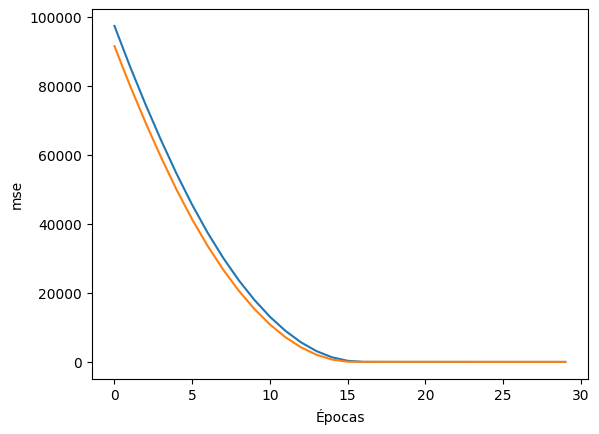

In [64]:
plt.plot(train_losses)
plt.plot(val_losses)
plt.xlabel('Épocas')
plt.ylabel('mse')
plt.show()

## Modelo 1

In [21]:
class gruregressor1(nn.Module):
    def __init__(self, seq_len, hidden_size):
        super().__init__()
        self.GRU1 = nn.GRU(input_size=seq_len, hidden_size=hidden_size, batch_first=True, bidirectional=True)
        self.attn = nn.Linear(2*hidden_size, 1)
        self.Linear1 = nn.Linear(in_features=2*hidden_size + 3, out_features=hidden_size)
        self.sigmoid = nn.Sigmoid()
        self.Linear2 = nn.Linear(in_features=hidden_size, out_features=1)

    def forward(self, input_seq, input_release_year, input_runtime, input_seasons):
        # input_seq: (batch, time, features)
        out, _ = self.GRU1(input_seq)
        # attention
        attn_weights = torch.softmax(self.attn(out).squeeze(-1), dim=1)  # (batch, time)
        context = torch.sum(out * attn_weights.unsqueeze(-1), dim=1)     # (batch, 2*hidden_size)
        
        # concatenar con las características numéricas
        context = torch.cat((context, input_release_year, input_runtime, input_seasons), dim=1)
        context = self.Linear1(context)
        context = self.sigmoid(context)
        outputs = self.Linear2(context)
        return outputs

In [22]:
LEARNING_RATE = 0.001
NUM_EPOCHS = 30
HIDDEN_SIZE = 32

# Inicializa el modelo 
model = gruregressor1(seq_len=768, hidden_size=HIDDEN_SIZE).to(device)

# Función de pérdida y optimizador
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

Modelo creado con 156258 parámetros


In [23]:
#### Entrenamiento del modelo #####
train_losses, val_losses = train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS)

Iniciando entrenamiento...
--------------------------------------------------
Época 5/30
  Pérdida Entrenamiento: 1.7573
  Pérdida Testeo: 1.7710
  Mejorando
Época 10/30
  Pérdida Entrenamiento: 1.7429
  Pérdida Testeo: 1.7711
  Empeorando
Época 15/30
  Pérdida Entrenamiento: 1.7430
  Pérdida Testeo: 1.7710
  Mejorando
Época 20/30
  Pérdida Entrenamiento: 1.7430
  Pérdida Testeo: 1.7709
  Mejorando
Época 25/30
  Pérdida Entrenamiento: 1.7430
  Pérdida Testeo: 1.7708
  Mejorando
Época 30/30
  Pérdida Entrenamiento: 1.7431
  Pérdida Testeo: 1.7708
  Mejorando
Entrenamiento completado! Tiempo total: 1169.60 segundos


In [37]:
del model, train_dataloader, val_dataloader

In [39]:
import gc
torch.cuda.empty_cache()
gc.collect()

0

## Modelo 3

In [33]:
class gruregressor1(nn.Module):
    def __init__(self, seq_len, hidden_size):
        super().__init__()
        self.GRU1 = nn.GRU(input_size=seq_len, hidden_size=hidden_size, batch_first=True, bidirectional=True)
        self.attn = nn.Linear(2*hidden_size, 1)
        self.Linear1 = nn.Linear(in_features=2*hidden_size + 3, out_features=hidden_size)
        self.sigmoid = nn.Sigmoid()
        self.Linear2 = nn.Linear(in_features=hidden_size, out_features=1)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, input_seq, input_release_year, input_runtime, input_seasons):
        # input_seq: (batch, time, features)
        out, _ = self.GRU1(input_seq)
        # attention
        attn_weights = torch.softmax(self.attn(out).squeeze(-1), dim=1)  # (batch, time)
        context = torch.sum(out * attn_weights.unsqueeze(-1), dim=1)     # (batch, 2*hidden_size)
        context = self.dropout(context)

        # concatenar con las características numéricas
        context = torch.cat((context, input_release_year, input_runtime, input_seasons), dim=1)
        context = self.Linear1(context)
        context = self.sigmoid(context)
        outputs = self.Linear2(context)
        return outputs

In [40]:
BATCH_SIZE = 64+32

# then create your loaders as before:
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=custom_collate)
val_dataloader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, collate_fn=custom_collate)

LEARNING_RATE = 0.001
NUM_EPOCHS = 30
HIDDEN_SIZE = 16

# Inicializa el modelo 
model = gruregressor1(seq_len=768, hidden_size=HIDDEN_SIZE).to(device)

# Función de pérdida y optimizador
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

print(f"Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

Modelo creado con 76082 parámetros


In [41]:
train_losses, val_losses = train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS)

Iniciando entrenamiento...
--------------------------------------------------
Época 5/30
  Pérdida Entrenamiento: 8.5809
  Pérdida Testeo: 6.8967
  Mejorando
Época 10/30
  Pérdida Entrenamiento: 1.7442
  Pérdida Testeo: 1.7417
  Mejorando
Época 15/30
  Pérdida Entrenamiento: 1.7443
  Pérdida Testeo: 1.7418
  Empeorando
Época 20/30
  Pérdida Entrenamiento: 1.7443
  Pérdida Testeo: 1.7418
  Empeorando
Época 25/30
  Pérdida Entrenamiento: 1.7444
  Pérdida Testeo: 1.7418
  Empeorando
Época 30/30
  Pérdida Entrenamiento: 1.7444
  Pérdida Testeo: 1.7418
  Empeorando
Entrenamiento completado! Tiempo total: 1221.98 segundos


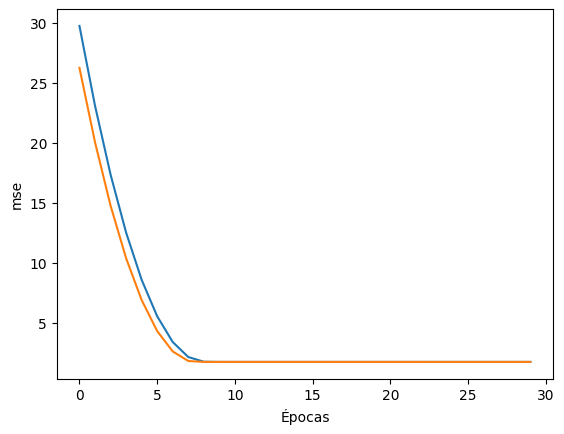

In [42]:
plt.plot(train_losses)
plt.plot(val_losses)
plt.xlabel('Épocas')
plt.ylabel('mse')
plt.show()

## Modelo x

In [ ]:
def transform_model1(dataframe):
    df = dataframe.copy()
    for feature in LINGUAL_FEATURES:
        df[feature] = df[feature].astype(str).apply(lambda txt: tokenizer.tokenize(txt))
    return df

titles_train = transform_model1(titles_train)
titles_val = transform_model1(titles_val)
titles_train.head()

,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,directors,actors,imdb_score
id,,,,,,,,,,,,
169347,"[St, ##eal, ##ing, Paradise]","[MO, ##VI, ##E]","[The, story, follows, a, br, ##ill, ##iant, en...",2012,[R],89,"[thriller, ,, drama]",[CA],1,"[Tristan, Dubois]","[Ra, ##cha, ##el, Leigh, Cook, ,, Richard, Rob...",5.6
22974,"[Mind, Games]","[SH, ##OW]","[Clark, and, Ross, Edwards, are, brothers, and...",2014,"[TV, -, PG]",43,"[drama, ,, thriller]",[US],1,[],"[Steve, Za, ##hn, ,, Christian, Slater, ,, Meg...",6.3
22345,"[Word, ##G, ##ir, ##l]","[SH, ##OW]","[Word, ##G, ##ir, ##l, is, an, American, child...",2007,"[TV, -, PG]",19,"[animation, ,, action, ,, comedy, ,, family, ,...",[US],9,[],"[Ryan, Rad, ##dat, ##z]",7.1
469433,"[Pac, ##to, de, Fu, ##ga]","[MO, ##VI, ##E]","[During, the, last, years, of, Pino, ##chet, '...",2020,[PG],138,"[drama, ,, thriller, ,, action]",[CL],1,"[David, Alba, ##la]","[Ben, ##jam, ##ín, Vic, ##u, ##ña, ,, Roberto,...",7.0
196046,"[Where, the, Road, Run, ##s, Out]","[MO, ##VI, ##E]","[George, ,, a, scientist, living, in, Rotterda...",2014,"[Un, ##rated]",91,"[romance, ,, drama, ,, family]","[NL, ,, Z, ##A, ,, G, ##Q]",1,"[Rudolf, Bu, ##iten, ##dach]","[Isaac, ##h, De, Bank, ##ol, ##é, ,, Juliet, L...",5.6


In [ ]:
from torch.utils.data import Dataset

class dataset_token(Dataset):
    def __init__(self, titles):
        self.pairs = list(zip(titles['title'],
                              titles['type'],
                              titles['description'],
                              titles['release_year'],
                              titles['age_certification'],
                              titles['runtime'],
                              titles['genres'],
                              titles['production_countries'],
                              titles['seasons'],
                              titles['directors'],
                              titles['actors'],
                              titles['imdb_score']))
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        title, type, description, release_year, age_certification, runtime, genres, production_countries, seasons, directors,actors, imdb_score = self.pairs[idx]
        out = {}

        for name, feat in zip(LINGUAL_FEATURES, [title, type, description, age_certification, genres, production_countries, directors, actors]):
            hidden = get_token_embedding(feat).to(device)
            out[f'input_{name}'] = hidden
            out[f'input_{name}_length'] = torch.tensor(hidden.shape[0]).to(device)

        for name, feat in zip(NUMERICAL_FEATURES, [release_year, runtime, seasons]):
            out[f'input_{name}'] = torch.tensor(feat, dtype=torch.float).to(device)
            out[f'input_{name}_length'] = torch.tensor(1).to(device)

        out['target'] = torch.tensor(imdb_score, dtype=torch.float).to(device)
        out['target_length'] = torch.tensor(1).to(device)
        return out

train_dataset = dataset_token(titles_train)
val_dataset = dataset_token(titles_val)

print('Primer elemento del dataset de entrenamiento:', train_dataset[1])

Primer elemento del dataset de entrenamiento: {'input_title': tensor([[-0.1124, -0.0422,  0.0225,  ..., -0.0460,  0.0178, -0.0278],
        [ 0.0122,  0.0135,  0.0171,  ..., -0.0164, -0.0590,  0.0161]],
       device='cuda:0', grad_fn=<IndexBackward0>), 'input_title_length': tensor(2, device='cuda:0'), 'input_type': tensor([[ 0.0357, -0.0080,  0.0463,  ..., -0.0006, -0.0786, -0.0812],
        [-0.0152, -0.0318, -0.0287,  ...,  0.0086, -0.0147,  0.0680]],
       device='cuda:0', grad_fn=<IndexBackward0>), 'input_type_length': tensor(2, device='cuda:0'), 'input_description': tensor([[-6.9011e-02, -3.6854e-02,  3.0901e-03,  ..., -3.9542e-02,
         -3.5362e-02,  3.1704e-02],
        [ 8.9002e-03, -1.5730e-02, -2.6894e-02,  ..., -3.8655e-04,
          8.8705e-03,  4.6704e-03],
        [-6.9211e-02, -2.7776e-02, -1.1194e-01,  ...,  4.6948e-02,
         -6.7945e-02, -2.7586e-03],
        ...,
        [-6.3258e-02, -1.8189e-02,  9.8494e-03,  ..., -4.2100e-02,
         -1.8919e-02, -1.1414e-

In [27]:
import time

def train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS):
    train_losses = []
    val_losses = []

    print("Iniciando entrenamiento...")
    print("-" * 50)
    start_time = time.time()
    for epoch in range(NUM_EPOCHS):
        # Entrenamiento
        model.train()
        train_loss = 0
        n = 0

        for batch_idx, batch in enumerate(train_dataloader):
            input = batch['input']
            target = batch['target'].unsqueeze(1).to(device)

            optimizer.zero_grad()

            output = model.forward(input)
            loss = criterion(output, target)

            loss.backward()

            # Gradient clipping para evitar exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_loss += loss.item()
            n += 1

        train_loss /= n
        train_losses.append(train_loss)

        # Validación
        model.eval()
        val_loss = 0
        m = 0
        with torch.no_grad():
            for batch_idx, batch in enumerate(val_dataloader):
                input = batch['input']
                target = batch['target'].unsqueeze(1).to(device)

                output = model.forward(input)
                loss = criterion(output, target)
                val_loss += loss.item()
                m += 1
        val_loss /= m
        val_losses.append(val_loss)

        if (epoch + 1) % 5 == 0:
            print(f'Época {epoch+1}/{NUM_EPOCHS}')
            print(f'  Pérdida Entrenamiento: {train_loss:.4f}')
            print(f'  Pérdida Testeo: {val_loss:.4f}')
            print(f'  {"Mejorando" if val_loss < min(val_losses[:-1] + [float("inf")]) else "Empeorando"}')
    
    end_time = time.time()
    print(f"Entrenamiento completado! Tiempo total: {end_time - start_time:.2f} segundos")
    return train_losses, val_losses